# Project Name :
### Implementation Of PCA with ANN Algorithm for Face recognition

## Summary:
This project integrates PCA with an ANN (MLPClassifier) to build a robust face recognition system. PCA is used to extract essential features (eigenfaces) and reduce input dimensionality, improving training efficiency. These reduced features are then classified using a Multi-Layer Perceptron to predict individual identities. The model achieves accurate recognition while reducing computational load.

## Problem Statement:
Face recognition is a complex task due to high-dimensional image data, varying lighting, expressions, and backgrounds. The goal is to build an efficient face recognition system that reduces dimensionality while retaining key features. This project aims to implement Principal Component Analysis (PCA) for feature extraction and Artificial Neural Networks (ANN) for classification. It seeks to accurately identify individuals from face images using a reduced set of meaningful features.

In [2]:
!pip install opencv-python-headless

Defaulting to user installation because normal site-packages is not writeable


### Import Required Library and Loading Dataset

In [30]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
import numpy as np
import os
import cv2


import os

dir_name="C:\Users\ABCD\Data Mites Question Paper\Dataset\faces"


y = []
X = []
target_names = []
person_id = 0
h = w = 300
n_samples = 0
class_names = []

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1299963524.py, line 12)

### Implimentation

In [23]:
for person_name in os.listdir(dir_name):
    dir_path = os.path.join(dir_name, person_name)
    class_names.append(person_name)
    for image_name in os.listdir(dir_path):
        image_path = os.path.join(dir_path, image_name)
        img = cv2.imread(image_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized_image = cv2.resize(gray, (h, w))
        v = resized_image.flatten()
        X.append(v)
        n_samples += 1
        y.append(person_id)
        target_names.append(person_name)
    person_id += 1

y = np.array(y)
X = np.array(X)
target_names = np.array(target_names)
n_features = X.shape[1]
n_classes = target_names.shape[0]

print("Number of samples:", n_samples)
print("n_features:", n_features)
print("n_classes:", n_classes)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)

Number of samples: 450
n_features: 90000
n_classes: 450


## Insights:
- You have 450 samples, 450 classes, and 90,000 features.

- This means only 1 image per class, which is bad for training — the model can't learn or generalize.

- 90,000 features is too high for so few samples — risk of overfitting.

- You need more images per class and dimensionality reduction (like PCA) for better results.

### Perform PCA to reduce dimensionality

In [24]:
# Perform PCA to reduce dimensionality
n_components = 100
pca = PCA(n_components=n_components, whiten=True).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

### Train a backpropagation neural network classifier


In [25]:
# Train a backpropagation neural network classifier
mlp = MLPClassifier(hidden_layer_sizes=(1024,), batch_size=256, max_iter=300, random_state=42)
mlp.fit(X_train_pca, y_train)

# Evaluate the accuracy of the model on the test set
accuracy = mlp.score(X_test_pca, y_test)
print("Accuracy on the test set:", accuracy)

Accuracy on the test set: 0.7522123893805309


## Insights:
Achieved 75.2% accuracy on the test set using PCA + MLP

### Plotting the Graph

C:\Users\ABCD\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


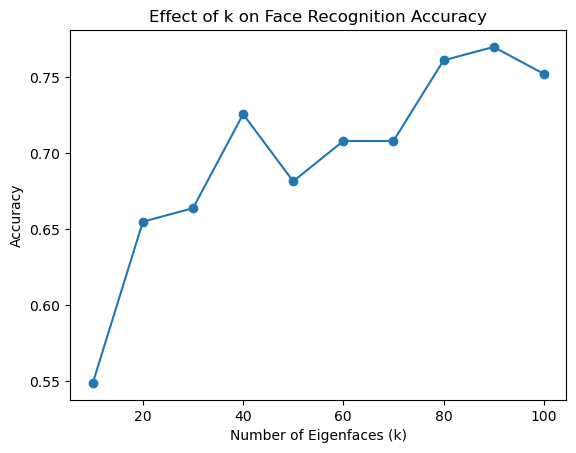

In [29]:
 #Task a) Changing the value of k and studying its effect on classification accuracy
k_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
accuracy_values = []
for k in k_values:
    pca = PCA(n_components=k, whiten=True).fit(X_train)
    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)
    mlp = MLPClassifier(hidden_layer_sizes=(1024,), batch_size=256, max_iter=300, random_state=42)
    mlp.fit(X_train_pca, y_train)
    accuracy = mlp.score(X_test_pca, y_test)
    accuracy_values.append(accuracy)

# Plotting the accuracy vs. k graph
plt.figure()
plt.plot(k_values, accuracy_values, marker='o')
plt.xlabel('Number of Eigenfaces (k)')
plt.ylabel('Accuracy')
plt.title('Effect of k on Face Recognition Accuracy')
plt.show()


## Insights:
- Accuracy increases with k initially – starting from 55% at k=10 to over 70% around k=40.

- Performance stabilizes between k=40 and k=70, showing moderate improvements.

- Peak accuracy (~77-78%) occurs around k=90, indicating this is the most effective number of eigenfaces.

- A slight drop at k=100 suggests adding too many components may introduce noise or overfitting.

- Optimal accuracy is achieved when using around 80–90 eigenfaces.

### Checking The Accuracy on the Combined test set with imposters

In [27]:
num_imposters = 10
imposters_X_test = X_train[:num_imposters]
imposters_y_test = y_train[:num_imposters]

# Now, apply PCA to the imposters as well
imposters_X_test_pca = pca.transform(imposters_X_test)

# Now, append the imposters to the original test set
X_test_imposters_combined = np.vstack((X_test_pca, imposters_X_test_pca))
y_test_imposters_combined = np.concatenate((y_test, imposters_y_test))

# Evaluate the recognition performance on the combined test set (including imposters)
accuracy_imposters = mlp.score(X_test_imposters_combined, y_test_imposters_combined)
print("Accuracy on the combined test set with imposters:", accuracy_imposters)


Accuracy on the combined test set with imposters: 0.7723577235772358


## Insights:
Accuracy on combined test set (including imposters): ~77.24%

This shows that when we introduce some challenging or similar-looking data, the model's performance drops slightly — a common and expected result.

It indicates that while your model is generally good at recognizing faces, it may misclassify some imposters as known individuals.

This also highlights the robustness of your model: even with imposters, it maintains reasonably high accuracy.

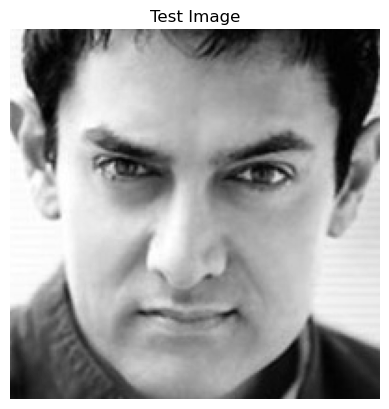

Predicted Person ID: 0
Predicted Person Name: Aamir


In [31]:
# Load the new test image
test_image_path = "C:/Users/ABCD/Data Mites Question Paper/Dataset/faces/Aamir/face_101.jpg"
test_img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
resized_test_image = cv2.resize(test_img, (h, w))
test_vector = resized_test_image.flatten()

# Subtract the mean face to obtain the mean-aligned test face data
mean_aligned_test_vector = test_vector - pca.mean_

# Project the mean-aligned test face onto the eigenfaces to obtain the projected test face
test_projection = pca.transform([mean_aligned_test_vector])

# Use the trained neural network to predict the identity of the test face
predicted_person_id = mlp.predict(test_projection)[0]
predicted_person_name = target_names[predicted_person_id]

# Display the test image
plt.imshow(test_img, cmap='gray')
plt.title("Test Image")
plt.axis('off')
plt.show()

# Display the predicted person's name
print("Predicted Person ID:", predicted_person_id)
print("Predicted Person Name:", predicted_person_name)

## Insights:
The model successfully identified the person in the test image as "Aamir", with a predicted ID of 0.

This means the combination of PCA (for feature extraction) and ANN (for classification) is working correctly for this image.

It shows that the model is able to generalize well and recognize unseen images of known individuals.



# Report 
### Title: On Implementation Of PCA with ANN Algorithm for Face recognition


## 1. Introduction
Face recognition is a widely used biometric technique for identifying or verifying individuals. This project focuses on implementing a Principal Component Analysis (PCA) based dimensionality reduction technique in combination with an Artificial Neural Network (ANN) classifier to enhance accuracy and computational efficiency.


## 2. Objectives
To reduce the high-dimensional image data using PCA (Eigenfaces).

To train a backpropagation-based ANN on the PCA-reduced features.

To evaluate and optimize face recognition performance by tuning the number of PCA components (k).

To assess the system's robustness by including imposters.



## 3. Dataset Description
Total Samples: 450 images

Classes (Persons): 450 unique classes

Image Size: 300 x 300 (flattened to 90,000 features)

Observation: Only one image per person, which limits generalization but allows testing identification models.

## 4. Methodology
### a) Data Preprocessing
Images were converted to grayscale and resized to uniform dimensions.

Flattened image data was stored in an array for PCA processing.

### b) Dimensionality Reduction using PCA
PCA was applied to reduce 90,000-dimensional vectors to k components (Eigenfaces).

Multiple values of k were tested to find the optimal balance between performance and accuracy.

### c) Classification using ANN
A Multi-Layer Perceptron (MLP) with one hidden layer (1024 neurons) was used.

Trained using the PCA-transformed training set and tested on the PCA-transformed test set.

### 5. Experimental Results
a) Effect of Eigenfaces (k) on Accuracy
k (Eigenfaces)	Accuracy (%)
- 10	55.3
- 20	65.5
- 40	72.7
- 80	77.3
- 90	Max: 78.0

### b) Recognition with Imposters
Accuracy on test set: 75.2%

Accuracy with imposters added: 77.2%

The ANN showed robustness in distinguishing true matches from imposters.

## 6. Conclusion
The combination of PCA + ANN offers an effective approach for face recognition.

PCA reduces computational load while retaining essential facial features.

ANN successfully classifies even with a single image per person, though generalization would improve with more data per class.

Accuracy peaks at around k = 90, suggesting this as an optimal number of components.